In [1]:
import glob
import json
import pandas as pd
mdc_dir = 'input_data/home/anarya.ray/gppop-prod/MDC_from_scratch/outdir_O3/'
posteriors = glob.glob(mdc_dir+'pop0a_chi1chi2right/*/bbh_result.json')

N_samples = 1e6
N = []
for i,fle in enumerate(posteriors):
    
    with open(fle,'r') as jf:
        data = json.load(jf)
        posterior = data['posterior']['content']
        if N_samples>len(posterior['chirp_mass']):
            N_samples = len(posterior['chirp_mass'])
    N.append(len(posterior['chirp_mass']))

print(posterior.keys())
print(N_samples,min(N),max(N),len(posteriors))

dict_keys(['mass_ratio', 'chirp_mass', 'theta_jn', 'chi_1', 'chi_2', 'luminosity_distance', 'dec', 'ra', 'psi', 'phase', 'geocent_time', 'log_likelihood', 'log_prior', 'reference_frequency', 'waveform_approximant', 'minimum_frequency', 'total_mass', 'mass_1', 'mass_2', 'a_1', 'cos_tilt_1', 'a_2', 'cos_tilt_2', 'phi_jl', 'phi_12', 'tilt_1', 'tilt_2', 'H1_log_likelihood', 'L1_log_likelihood', 'V1_log_likelihood', 'H1_matched_filter_snr', 'H1_optimal_snr', 'L1_matched_filter_snr', 'L1_optimal_snr', 'V1_matched_filter_snr', 'V1_optimal_snr', 'symmetric_mass_ratio', 'iota', 'spin_1x', 'spin_1y', 'spin_1z', 'spin_2x', 'spin_2y', 'spin_2z', 'phi_1', 'phi_2', 'chi_eff', 'chi_1_in_plane', 'chi_2_in_plane', 'chi_p', 'redshift', 'comoving_distance', 'mass_1_source', 'mass_2_source', 'chirp_mass_source', 'total_mass_source'])
3343 3343 4901 276


In [2]:
import numpy as np

posterior_samples_all = np.zeros((len(posteriors),N_samples,3))
spin_priors = [ ]
np.random.seed(2**31-78)
n=0
for i,fle in enumerate(posteriors):
    
    with open(fle,'r') as jf:
        data = json.load(jf)
        m1= np.array(data['posterior']['content']['mass_1'])
        m2 = np.array(data['posterior']['content']['mass_2'])
        z = np.array(data['posterior']['content']['luminosity_distance'])
        # chi_eff =np.array(data['posterior']['content']['chi_eff'])
        # time = data['injection_parameters']['geocent_time']
       
        indices = np.random.choice(len(m1),size=N_samples,replace=False)
        
        # spin_priors.append(np.exp(spin_prior._logprob(chi_eff,
        #                                               m1,
        #                                               m2,0.99))[indices])
        posterior_samples_all[n,:,:] = np.array([m1,m2,z]).T[indices,:]
        n+=1

# spin_priors = np.array(spin_priors)
print(posterior_samples_all.shape)



(276, 3343, 3)


In [12]:
rng = np.random.default_rng(1000)

# 2. Find out how many total events are in the full array (e.g., 250)
total_events = len(posterior_samples_all)

# 3. Draw 69 random, unique indices (replace=False ensures no duplicates)
random_indices = rng.choice(total_events, size=250, replace=False)

# 4. Apply the random mask 
# (Use this line if posterior_samples_all is a NumPy or JAX array)
test_pos = posterior_samples_all[random_indices]

In [14]:
# test_pos = posterior_samples_all[0:69]

In [13]:
import matplotlib.pyplot as plt
m1det = np.concatenate([post[:, 0] for post in test_pos])
m2det = np.concatenate([post[:, 1] for post in test_pos])
dL = np.concatenate([post[:, 2] for post in test_pos])

(array([2.48597e+05, 1.58037e+05, 2.58008e+05, 1.19337e+05, 3.21690e+04,
        1.24540e+04, 5.26200e+03, 1.60100e+03, 2.59000e+02, 2.60000e+01]),
 array([  7.7977098 ,  25.77148889,  43.74526799,  61.71904708,
         79.69282617,  97.66660526, 115.64038435, 133.61416344,
        151.58794253, 169.56172163, 187.53550072]),
 <BarContainer object of 10 artists>)

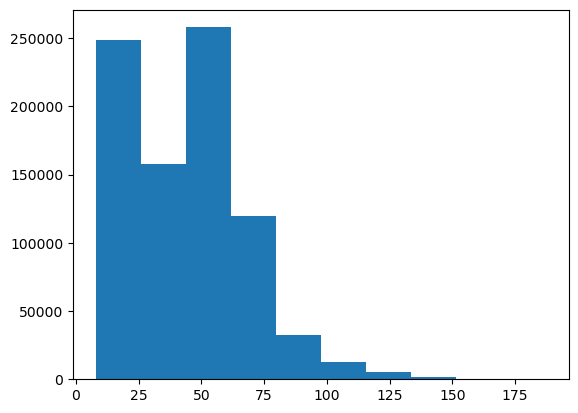

In [14]:
plt.hist(m1det)

In [15]:
import numpy as np
np.savetxt('input_data/mdc_m1det_250rand.txt', m1det)
np.savetxt('input_data/mdc_m2det_250rand.txt', m2det)
np.savetxt('input_data/mdc_dL_250rand.txt', dL)